In [1]:
import os
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('default')
import src.reader_functions as rf
import os
import importlib
importlib.reload(rf)


<module 'src.reader_functions' from 'C:\\Users\\owner\\Documents\\Projects\\dysregulated-persistence\\src\\reader_functions.py'>

concatenate data from two files

In [ ]:
# load data:
data_dir = os.path.join(os.path.dirname(os.getcwd()),'reader_data', 'SYTOX_23_03_25')
data_file1 = '23_03_25.xlsx'
data_file2 = '23_03_25_with_cherry_2.xlsx'
# starting time of each data file:
time1 = "12:44:47"
time2 = "18:42:40"
read=1# read number, 1 - OD, 2- Blue fluorescence, 3 - Read fluorescence
# convert time to datetime.time object:
time1 = datetime.time(*map(int, time1.split(':')))
time2 = datetime.time(*map(int, time2.split(':')))
# read data from each file:
data_sheet1 = pd.read_excel(os.path.join(data_dir, data_file1), sheet_name='Plate 1 - Sheet1', header=14)
read_data1 = rf.get_read_data(data_sheet1, 'Time', read)
data_sheet2 = pd.read_excel(os.path.join(data_dir, data_file2), sheet_name='Plate 1 - Sheet1', header=14)
read_data2 = rf.get_read_data(data_sheet2, 'Time', read)
# concatenate data from two files:
data = rf.concat_read_data(read_data1, read_data2, time1,time2)
# save data:
data.to_csv(os.path.join(data_dir, f'Read{read}_concatenated.csv'))

Plot the data after removing the background fluorescence and cell autofluorescence

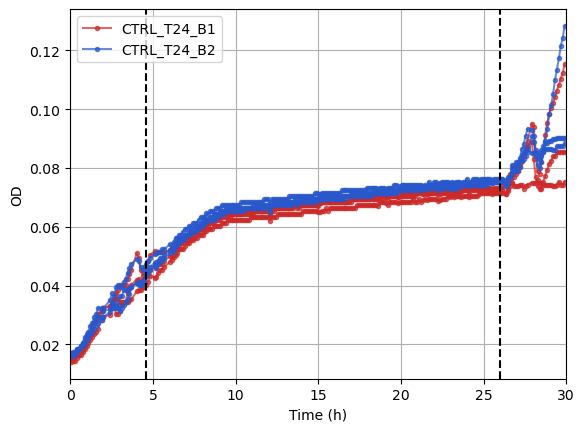

0.07400000000000001


In [ ]:
# plot normalized data curves:
treatment = 'CTRL'
time = '24'
channel = 'OD'
data_dir = os.path.join(os.path.dirname(os.getcwd()),'reader_data', 'SYTOX_23_03_25')
data_file = 'Read1_concatenated.csv'
read_data = pd.read_csv(os.path.join(data_dir, data_file), header=0, index_col=0)
read_data = read_data.iloc[:-3]

legend_handles = {}  # Store unique legend entries
color_gen = rf.DistinctColorGenerator()
# plot curves
plate_info = 'plate_info.csv'
conditions = [f'{treatment}_T{time}_B1', f'{treatment}_T{time}_B2']
medium = f'M9_{treatment}_T{time}'
condition_locations = rf.extract_condition_locations(os.path.join(data_dir, plate_info))
time = read_data.index/60
values = []
for i in range(len(conditions)):
    color = color_gen.get_new_color()
    if channel == 'SytoxBlue':
        cells_background = f'{treatment}_'+conditions[i].split('_')[-1]
        cells_background_wells = condition_locations[cells_background]
        if treatment != 'EXP':
            medium_background_well = condition_locations[medium]
            background_well = condition_locations[f'M9_{treatment}']
            background = np.mean(read_data[cells_background_wells],axis=1)+np.mean(read_data[medium_background_well], axis=1)-np.mean(read_data[background_well],axis=1)
        else:
            background_well = condition_locations['M9_VAPC']
            background = np.mean(read_data[cells_background_wells],axis=1)+rf.shift_medium_fluoresence(read_data['B11'],read_data['B2'])-np.mean(read_data[background_well],axis=1)
    else:
        background_well = condition_locations[f'M9_{treatment}']
        background = np.mean(read_data[background_well],axis=1)
        
    for well in condition_locations[conditions[i]]:
        line = plt.plot(time, read_data[well]-background,marker='.',label=well, color = color, alpha = 0.7)
        values.append((read_data[well]-background).iloc[t24_ind-6])
        if conditions[i] not in legend_handles:
            legend_handles[conditions[i]] = line[0]
plt.xlabel('Time (h)')
plt.xlim([0,30])
#plt.ylim([0,0.2])
plt.ylabel(channel)
plt.legend(legend_handles.values(), legend_handles.keys(), loc='upper left')
plt.grid()
# plot vertical lines at 2h and 24h
plt.axvline(x=time[t2_ind+3], color='black', linestyle='--')
plt.axvline(x=time[t24_ind-6], color='black', linestyle='--')
plt.show()
print(np.mean(values))

Plot raw well data

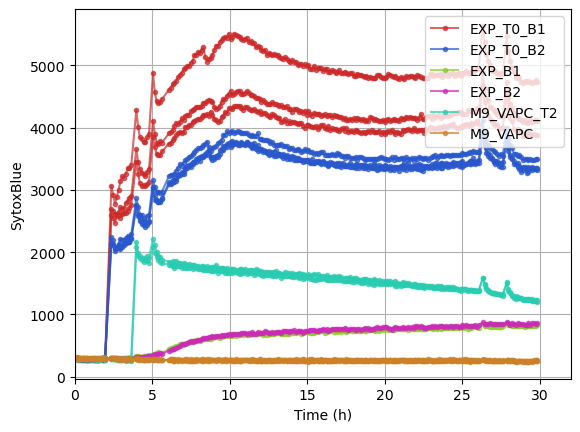

In [ ]:
treatment = 'VAPC'
time = '24'
channel = 'OD'
data_dir = os.path.join(os.path.dirname(os.getcwd()),'reader_data', 'SYTOX_23_03_25')
data_file = 'Read1_concatenated.csv'
read_data = pd.read_csv(os.path.join(data_dir, data_file), header=0, index_col=0)
read_data = read_data.iloc[:-3]

legend_handles = {}  # Store unique legend entries
color_gen = rf.DistinctColorGenerator()

plate_info = 'plate_info.csv'
conditions = ['VAPC_T2_B1','VAPC_T2_B2', 'VAPC_T24', 'VAPC','EXP_B2','M9_VAPC_T2', 'M9_VAPC']
condition_locations = rf.extract_condition_locations(os.path.join(data_dir, plate_info))
time = read_data.index / 60
for i in range(len(conditions)):
    color = color_gen.get_new_color()
    for well in condition_locations[conditions[i]]:
        line = plt.plot(time, read_data[well], marker='.', label=well, color=color, alpha=0.7)
        if conditions[i] not in legend_handles:
            legend_handles[conditions[i]] = line[0]
plt.xlabel('Time (h)')
plt.xlim([0,32])
#plt.ylim([0,0.2])
plt.ylabel(channel)
plt.legend(legend_handles.values(), legend_handles.keys(), loc='upper right')
plt.grid()
plt.show()

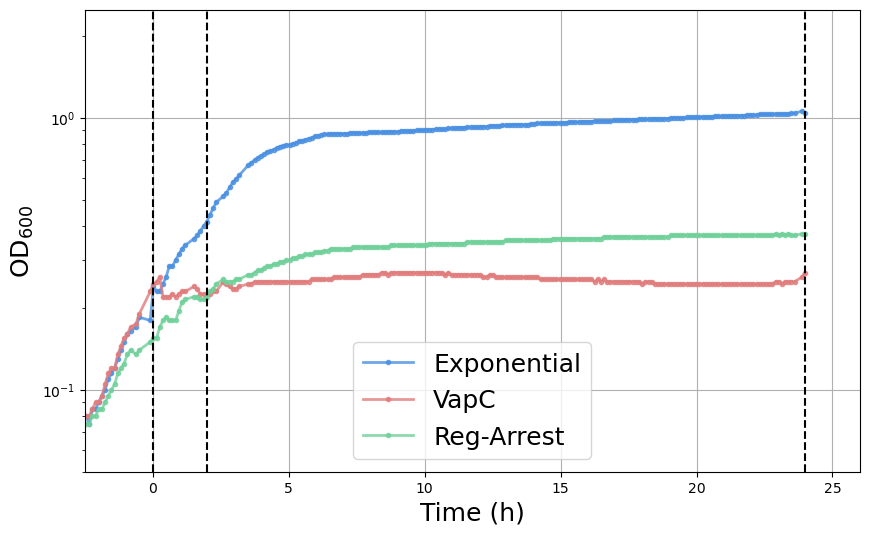

In [2]:
# OD plots for specific wells:
data_dir = os.path.join(os.path.dirname(os.getcwd()),'reader_data', 'SYTOX_23_03_25')
data_file = 'Read1_concatenated.csv'
read_data = pd.read_csv(os.path.join(data_dir, data_file), header=0, index_col=0)
read_data = read_data.iloc[:-3]
f_size = 18
colors = ['#4A90E2','#E17C7C','#70D09A']
labels = ['Exponential','VapC','Reg-Arrest']

plate_info = 'plate_info.csv'
wells = ['B2','D4','F5']
medium = 'B10'
time = read_data.index / 60-2.5
fig,ax = plt.subplots(figsize=(10,6))
for i in range(len(wells)):
    # find index where time exceeds value
    y_data = 5*(read_data[wells[i]]-read_data[medium]) # factor 5 to compensate for 96 well plate OD
    ind = np.where(time>24)[0][0]
    line = plt.plot(time[:ind], y_data.iloc[:ind], marker='.',linewidth=2, label=labels[i], color=colors[i], alpha=.8)
        
# add dashed vertical lines at 0,2 and 24 hours
plt.axvline(x=0, color='black', linestyle='--')
plt.axvline(x=24, color='black', linestyle='--')
plt.axvline(x=2, color='black', linestyle='--')

plt.xlabel('Time (h)', fontsize = f_size)
plt.xlim([-2.5,26])
plt.ylim([5e-2,2.5])
plt.yscale('log')
plt.ylabel('OD$_{600}$', fontsize = f_size)
plt.legend(fontsize = f_size)
plt.grid()
# save as svg
output_dir = r"G:\Other computers\My MacBook Air\Alon\PhD\correlations paper\new figures\supplementary figures"
plt.savefig(os.path.join(output_dir, 'OD_1.svg'))
plt.show()

Create barplots to compare the fluorescence between time points

In [ ]:
# get data for bar plots of values at 2h and 24h
# load data:
data_dir = os.path.join(os.path.dirname(os.getcwd()),'reader_data', 'SYTOX_23_03_25')
data_file = 'Read2_concatenated.csv'
read_data = pd.read_csv(os.path.join(data_dir, data_file), header=0, index_col=0)
read_data = read_data.iloc[:-3]
treatment = 'VAPC'
legend_handles = {}  # Store unique legend entries
color_gen = rf.DistinctColorGenerator()
# plot OD curves
plate_info = 'plate_info.csv'
condition_locations = rf.extract_condition_locations(os.path.join(data_dir, plate_info))
data_for_barplot = {}
background_error = {}
# find time where well crosses threshold
t2_ind = np.where(read_data['C2']>1000)[0][0]+3
t24_ind = np.where(read_data['D2']>2000)[0][0]+6
ind = [t2_ind, t24_ind]
time = read_data.index /60
for k,t in enumerate([2,24]):
    conditions = [f'{treatment}_T{t}_B1',f'{treatment}_T{t}_B2']
    medium = f'M9_{treatment}_T{t}'
    for i in range(len(conditions)):
        data_for_barplot[conditions[i]] = []
        if channel == 'SytoxBlue':
            cells_background = f'{treatment}_'+conditions[i].split('_')[-1]
            cells_background_wells = condition_locations[cells_background]
            medium_background_well = condition_locations[medium]
            background_well = condition_locations[f'M9_{treatment}']
            background = np.mean(read_data[cells_background_wells],axis=1)+np.mean(read_data[medium_background_well], axis=1)-np.mean(read_data[background_well],axis=1)
            background_squared_error = np.var(read_data[cells_background_wells],axis=1)+np.var(read_data[medium_background_well], axis=1)+np.var(read_data[background_well],axis=1)
        else:
            background_well = condition_locations[f'M9_{treatment}']
            background = np.mean(read_data[background_well],axis=1)
            background_squared_error = np.var(read_data[background_well],axis=1)
        
        background_error[conditions[i]]=background_squared_error.iloc[ind[k]]   
        for well in condition_locations[conditions[i]]:
            normalized_value = read_data[well]-background
            data_for_barplot[conditions[i]].append(normalized_value.iloc[ind[k]])
            


# Define groups and time points
times = ['T2', 'T24']
reps = ['B1', 'B2']

# Compute means and standard errors
means = {tp: [] for tp in times}
errors = {tp: [] for tp in times}

for time in times:
    for rep in reps:
        key = f'{treatment}_{time}_{rep}'
        values = data_for_barplot[key]
        means[time].append(np.mean(values))
        errors[time].append(np.sqrt(np.var(values)+np.var(background_error[key])))  # Standard error

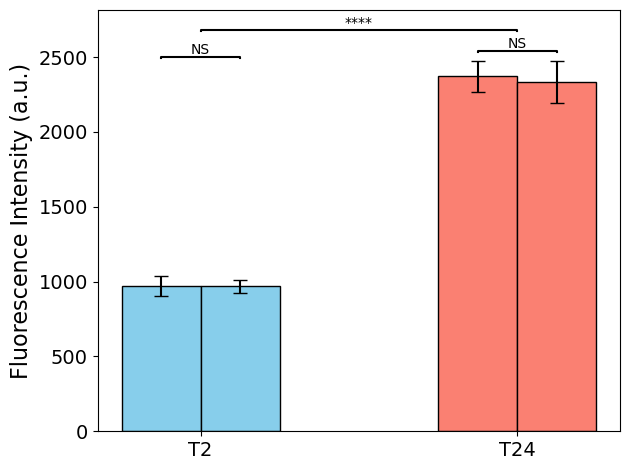

In [47]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import t

# get p-value for t-test
def get_pval(means, errors, n1, n2):
    tstat = (means[0] - means[1]) / np.sqrt(errors[0]**2/n1 + errors[1]**2/n2)
    df = n1 + n2 - 2
    return 2*t.sf(np.abs(tstat), df)

n=3
# T-tests
p_within_T2 = get_pval(means['T2'], errors['T2'], n, n)
p_within_T24 = get_pval(means['T24'], errors['T24'], n, n)
p_between = get_pval([means['T2'][0], means['T24'][0]], [errors['T2'][0], errors['T24'][0]], n, n)

# Significance formatting
def format_p(p):
    if p < 0.0001:
        return '****'
    elif p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'NS'

# Plotting
groups = list(means.keys())
num_bars = 2
bar_width = 0.1
spacing = 0.2

x = []
positions = []
current_pos = 0
for group in groups:
    for i in range(num_bars):
        x.append(current_pos)
        current_pos += bar_width
    current_pos += spacing

bar_values = sum([means[g] for g in groups], [])
bar_errors = sum([errors[g] for g in groups], [])
group_colors = ['skyblue', 'salmon']
bar_colors = sum([[color]*num_bars for color in group_colors], [])

fig, ax = plt.subplots()

bars = ax.bar(x, bar_values, yerr=bar_errors, capsize=5,
              width=bar_width, color=bar_colors, edgecolor='black')

# Labels
ax.set_ylabel('Fluorescence Intensity (a.u.)', fontsize=16)
ax.set_xticks([(x[i] + x[i+1])/2 for i in range(0, len(x), 2)])
ax.set_xticklabels(groups)
# fontsize
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Significance annotations
def annotate_sig(ax, x1, x2, y, text, h=5):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c='k')
    ax.text((x1 + x2)/2, y + h + 2, text, ha='center', va='bottom')

# Positions of the bars
y_max = max(bar_values[i] + bar_errors[i] for i in range(len(bar_values)))

# Within-group annotations
annotate_sig(ax, x[0], x[1], y_max + 20, format_p(p_within_T2))
annotate_sig(ax, x[2], x[3], y_max + 60, format_p(p_within_T24))

# Between-group annotation (compare group averages)
mid_T2 = (x[0] + x[1]) / 2
mid_T24 = (x[2] + x[3]) / 2
annotate_sig(ax, mid_T2, mid_T24, y_max + 200, format_p(p_between))

plt.tight_layout()
plt.show()


SHX treatment:

In [ ]:
# Load data:
data_dir = os.path.join(os.getcwd(),'data', 'SYTOX_23_03_25')
data_file = 'shx_sytox.xlsx'
read = 2 # read 2 for fluorescence data
data_sheet = pd.read_excel(os.path.join(data_dir, data_file), sheet_name='Plate 1 - Sheet1', header=14)
read_data = rf.get_read_data(data_sheet, 'Time', read)
read_data

In [ ]:
# plot normalized data curves:
treatment = 'SHX'
time = '24'
channel = 'SytoxBlue'
legend_handles = {}  # Store unique legend entries
color_gen = rf.DistinctColorGenerator()
# plot OD curves
plate_info = 'plate_info_shx.csv'
conditions = [f'{treatment}_T{time}']
medium = f'M9_T{time}'
condition_locations = rf.extract_condition_locations(os.path.join(data_dir, plate_info))
time = read_data.index/60 - 16
for i in range(len(conditions)):
    color = color_gen.get_new_color()
    if channel == 'SytoxBlue':
        cells_background = f'{treatment}'
        cells_background_wells = condition_locations[cells_background]
        medium_background_well = condition_locations[medium]
        background_well = condition_locations[f'M9']
        background = np.mean(read_data[cells_background_wells],axis=1)+np.mean(read_data[medium_background_well], axis=1)-np.mean(read_data[background_well],axis=1)
    else:
        background_well = condition_locations[f'M9']
        background = np.mean(read_data[background_well],axis=1)
        
    for well in condition_locations[conditions[i]]:
        line = plt.plot(time, read_data[well]-background,marker='.',label=well, color = color, alpha = 0.7)
        if conditions[i] not in legend_handles:
            legend_handles[conditions[i]] = line[0]
plt.xlabel('Time (h)')
plt.xlim([20,25])
#plt.ylim([0,0.2])
plt.ylabel(channel)
plt.legend(legend_handles.values(), legend_handles.keys(), loc='upper right')
plt.grid()
plt.show()

In [ ]:
# get data for bar plots:
# find time where well crosses threshold
ind = np.where(read_data['B2']>1000)[0][0]+8
time = read_data.index /60
condition = 'SHX_T24'
medium = f'M9_T24'
data_for_barplot={}
data_for_barplot[condition] = []
background_error = {}
cells_background = 'SHX'
cells_background_wells = condition_locations[cells_background]
medium_background_well = condition_locations[medium]
background_well = condition_locations[f'M9']
background = np.mean(read_data[cells_background_wells],axis=1)+np.mean(read_data[medium_background_well], axis=1)-np.mean(read_data[background_well],axis=1)


for well in condition_locations[conditions[i]]:
    normalized_value = read_data[well]-background
    data_for_barplot[condition].append(normalized_value.iloc[ind])
        

# Compute means and standard errors
mean = np.mean(data_for_barplot[condition])
error = np.std(data_for_barplot[condition])

print(f'{condition}: {mean} +- {error}')

In [ ]:
legend_handles = {}  # Store unique legend entries
color_gen = rf.DistinctColorGenerator()
treatment = 'SHX'
time = '24'
channel = 'SytoxBlue'
plate_info = 'plate_info_shx.csv'
conditions = ['SHX_T24', 'M9']
condition_locations = rf.extract_condition_locations(os.path.join(data_dir, plate_info))
time = read_data.index / 60
for i in range(len(conditions)):
    color = color_gen.get_new_color()
    for well in condition_locations[conditions[i]]:
        line = plt.plot(time, read_data[well], marker='.', label=well, color=color, alpha=0.7)
        if conditions[i] not in legend_handles:
            legend_handles[conditions[i]] = line[0]
plt.xlabel('Time (h)')
plt.xlim([10,20])
#plt.ylim([0,0.2])
plt.ylabel(channel)
plt.legend(legend_handles.values(), legend_handles.keys(), loc='upper right')
plt.grid()
plt.show()